# Manual EDA and checks

In [19]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Features for synthetic simulations tuned to theoretical values

In [20]:
calib_data = pd.read_excel('results/calibration_data.xlsx', sheet_name="synth by theoretical")

In [3]:
feature_order = ['phi_trans','phi_tan','phi_rad','phi_tan_unsigned','phi_local']
hue_order = ['Theoretical (10 fish)','Synthetic dataset','Real dataset']
feature_labels = {
    "phi_trans": r"$\Phi_{\mathrm{trans}}$",
    "phi_tan":   r"$\Phi_{\mathrm{tan}}$",
    "phi_rad":   r"$\Phi_{\mathrm{rad}}^{\pm}$",
    "phi_tan_unsigned": r"$\Phi_{\mathrm{tan}}^{\mathrm{unsigned}}$",
    "phi_local": r"$\Phi_{\mathrm{local}}$",
}

In [4]:
behavior_order = calib_data["behavior"].drop_duplicates().tolist()
colors = ['#5C847C','#E5943D','#7DC4BE']

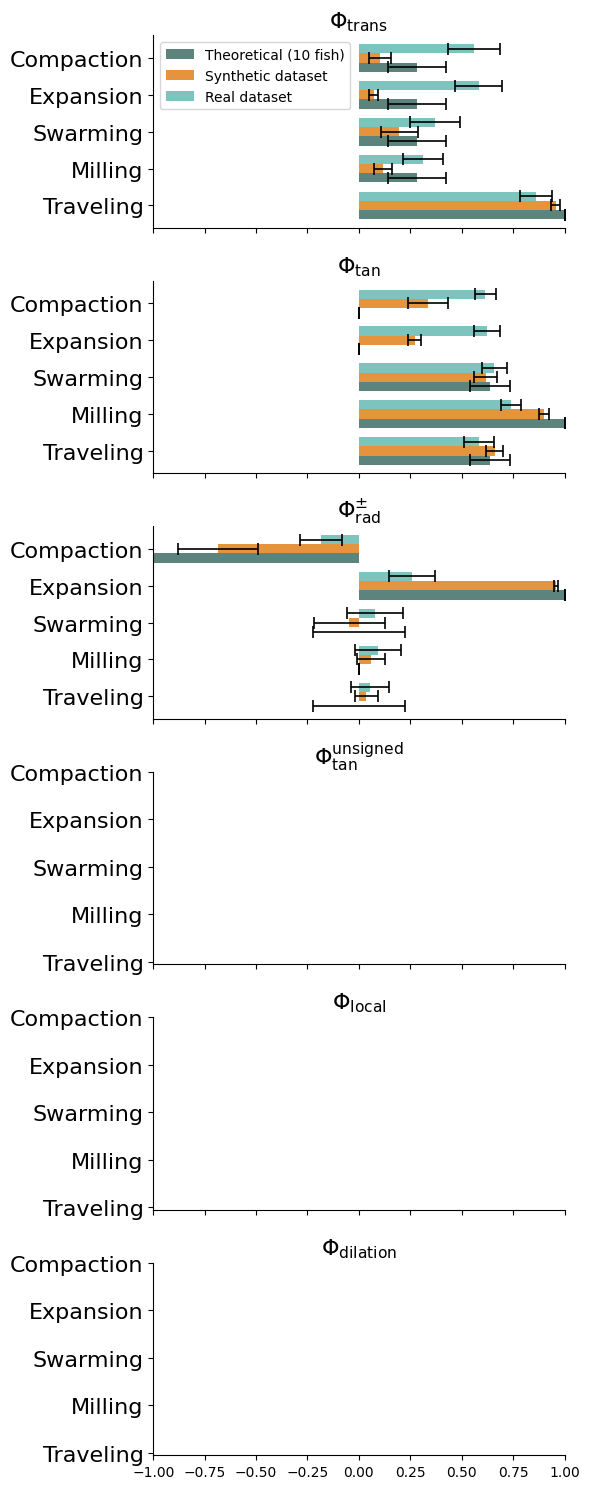

In [5]:
fig, axes = plt.subplots(
    len(feature_order),
    1,
    figsize=(6, 2.5 * len(feature_order)),
    sharex=True,
)

axes = np.atleast_1d(axes)

bar_height = 0.25
offsets = (
    np.arange(len(hue_order))
    - (len(hue_order) - 1) / 2
) * bar_height


def plot_feature(feature: str, axis_id: int):
    ax = axes[axis_id]
    y = np.arange(len(behavior_order))

    for i, dataset in enumerate(hue_order):
        sub = (
            calib_data[
                (calib_data["feature"] == feature)
                & (calib_data["dataset"] == dataset)
            ]
            .set_index("behavior")
            .reindex(behavior_order)
        )

        means = sub["feature mean"].to_numpy(dtype=float)
        stds = sub["feature std"].to_numpy(dtype=float)
        positions = y + offsets[i]
        valid = ~np.isnan(means)

        ax.barh(
            positions[valid],
            means[valid],
            height=bar_height,
            xerr=stds[valid],
            capsize=4,
            color=colors[i],
            label=dataset,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2,
            },
        )

    ax.set_yticks(y)
    ax.set_yticklabels(
        [behavior.capitalize() for behavior in behavior_order],
        fontsize=16,
    )
    ax.set_title(feature_labels[feature], fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(-1.0, 1.0)

    if axis_id == 0:
        ax.legend(frameon=True)


for axis_id, feature in enumerate(feature_order):
    plot_feature(feature=feature, axis_id=axis_id)

sns.despine()
plt.tight_layout()
plt.show()


## Features for synthetic simulations tuned to real dataset

In [26]:
ROOT = Path(".")
BEH_MAP = {
    "traveling_polarized": "traveling",
    "milling": "milling",
    "shoaling": "shoaling",
    "expansion_burst": "expansion",
    "compaction": "compaction",
}
FEAT_MAP = {
    "phi_trans": "phi_trans",
    "phi_tan": "phi_tan",
    "phi_rad_pm": "phi_rad",
    "phi_tan_unsigned": "phi_tan_unsigned",
    "phi_local": "phi_local",
}
BEHAVIOR_ORDER = ["traveling", "milling", "shoaling", "expansion", "compaction"]

THEORETICAL = {
    "traveling": {
        "phi_trans": 1.0,
        "phi_tan": 0.01,
        "phi_rad": 0.01,
        "phi_tan_unsigned": 0.01,
        "phi_local": 1.0,
    },
    "milling": {
        "phi_trans": 0.01,
        "phi_tan": 1.0,
        "phi_rad": 0.01,
        "phi_tan_unsigned": 1.0,
        "phi_local": 1.0,
    },
    "shoaling": {
        "phi_trans": 0.01,
        "phi_tan": 0.01,
        "phi_rad": 0.01,
        "phi_tan_unsigned": 0.01,
        "phi_local": 0.01,
    },
    "expansion": {
        "phi_trans": 0.01,
        "phi_tan": 0.01,
        "phi_rad": 1.0,
        "phi_tan_unsigned": 0.01,
        "phi_local": 0.01,
    },
    "compaction": {
        "phi_trans": 0.01,
        "phi_tan": 0.01,
        "phi_rad": -1.0,
        "phi_tan_unsigned": 0.01,
        "phi_local": 0.01,
    },
}


def _rows_from_features(features_by_behavior: dict, dataset: str) -> list[dict]:
    rows = []
    for canon, short in BEH_MAP.items():
        block = features_by_behavior.get(canon, {})
        feats = block.get("features", block)
        for json_name, plot_name in FEAT_MAP.items():
            stats = feats.get(json_name) or feats.get(f"{json_name}_mean", {})
            rows.append(
                {
                    "behavior": short,
                    "dataset": dataset,
                    "feature": plot_name,
                    "feature mean": float(stats.get("mean", float("nan"))),
                    "feature std": float(stats.get("std", float("nan"))),
                }
            )
    return rows


with open(ROOT / "results" / "calibration_report.json", encoding="utf-8") as f:
    couzin = json.load(f)
with open(ROOT / "results" / "tuning" / "feature_match" / "best.json", encoding="utf-8") as f:
    tuned = json.load(f)

rows = []
for short, feats in THEORETICAL.items():
    for feat, mean in feats.items():
        rows.append(
            {
                "behavior": short,
                "dataset": "Theoretical",
                "feature": feat,
                "feature mean": mean,
                "feature std": 0.0,
            }
        )
rows.extend(_rows_from_features(tuned["sim_features"], "Synthetic dataset"))
rows.extend(_rows_from_features(couzin, "CouzinLab dataset"))
calib_data = pd.DataFrame(rows)

In [27]:
feature_order = ['phi_trans','phi_tan','phi_rad','phi_tan_unsigned','phi_local']
hue_order = ['Theoretical','Synthetic dataset','CouzinLab dataset']
feature_labels = {
    "phi_trans": r"$\Phi_{\mathrm{trans}}$",
    "phi_tan":   r"$\Phi_{\mathrm{tan}}$",
    "phi_rad":   r"$\Phi_{\mathrm{rad}}^{\pm}$",
    "phi_tan_unsigned": r"$\Phi_{\mathrm{tan}}^{\mathrm{unsigned}}$",
    "phi_local": r"$\Phi_{\mathrm{local}}$",
}

In [28]:
behavior_order = [b for b in BEHAVIOR_ORDER if b in set(calib_data["behavior"])]
colors = ['#5C847C','#E5943D','#7DC4BE']

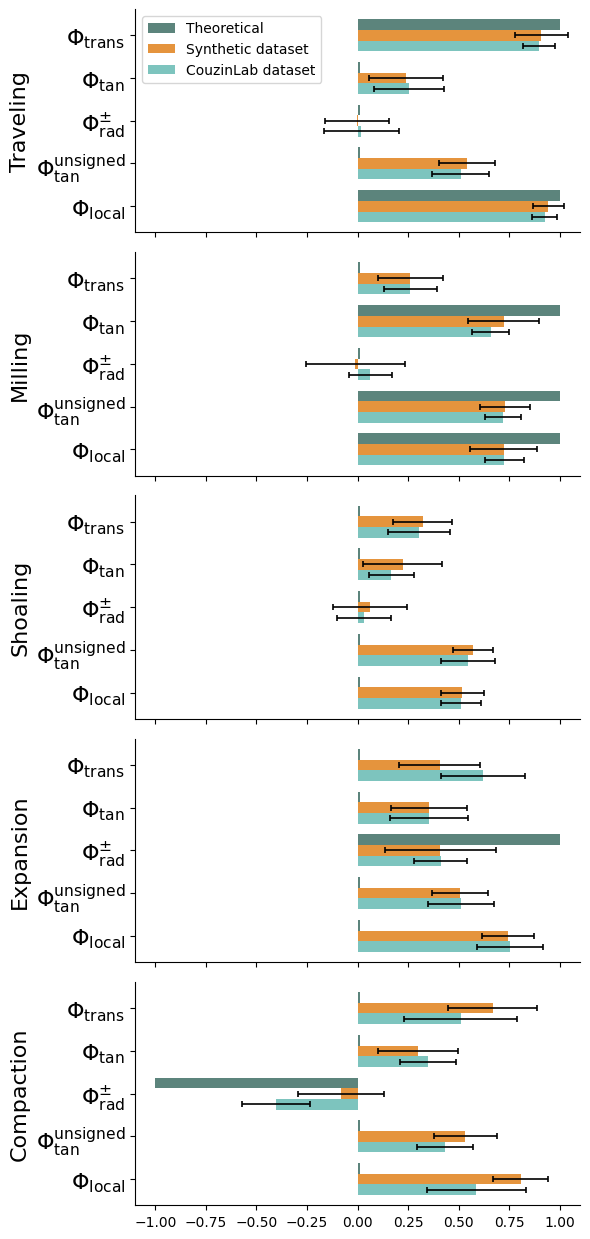

In [29]:
fig, axes = plt.subplots(
    len(behavior_order),
    1,
    figsize=(6, 2.5 * len(behavior_order)),
    sharex=True,
)

# Makes sure axes is always iterable even if there is only one subplot
axes = np.atleast_1d(axes)

def plot_behavior(behavior: str, axis_id: int):

    ax = axes[axis_id]

    # Filter dataframe
    d = calib_data[calib_data["behavior"] == behavior].copy()

    # Y positions of the three features
    y = np.arange(len(feature_order))

    # Height of each individual bar
    bar_height = 0.25

    # Offsets for hue:
    # dataset 1 -> bottom
    # dataset 2 -> center
    # dataset 3 -> top
    offsets = (
        np.arange(len(hue_order))
        - (len(hue_order) - 1) / 2
    ) * bar_height

    # -----------------------------------------------------
    # Draw each dataset separately
    # -----------------------------------------------------

    for i, dataset in enumerate(hue_order):

        sub = (
            d[d["dataset"] == dataset]
            .set_index("feature")
            .reindex(feature_order)
        )

        means = sub["feature mean"].to_numpy(dtype=float)
        stds = sub["feature std"].to_numpy(dtype=float)

        positions = y + offsets[i]

        # Handle missing combinations safely
        valid = ~np.isnan(means)
        if i == 0:
            ax.barh(
                positions[valid],
                means[valid],
                height=bar_height,
                color=colors[i],
                label=dataset,
            )
        else:
            ax.barh(
                positions[valid],
                means[valid],
                height=bar_height,
                xerr=stds[valid],
                capsize=2,
                color=colors[i],
                label=dataset,
                error_kw={
                    "elinewidth": 1.2,
                    "capthick": 1.2
                }
            )
    # -----------------------------------------------------
    # Axis formatting
    # -----------------------------------------------------

    ax.set_yticks(y)
    ax.set_yticklabels(
        [feature_labels[f] for f in feature_order],
        fontsize=16
    )
    ax.invert_yaxis()

    ax.set_ylabel(
        behavior.capitalize(),
        fontsize=16,
    )

    ax.set_xlabel("")

    ax.set_xlim(-1.1, 1.1)

    # Only show legend in first subplot
    if axis_id == 0:
        ax.legend(frameon=True)


# ---------------------------------------------------------
# Plot all behaviors
# ---------------------------------------------------------

for axis_id, behavior in enumerate(behavior_order):
    plot_behavior(
        behavior=behavior,
        axis_id=axis_id
    )


# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

sns.despine()

plt.tight_layout()

plt.savefig('results/behavior_bars.png', dpi=300)

plt.show()
